
## <h1><center>Clasificación binaria con Keras</center></h1>

## <center>Acerca de los datos </center>

Usaemos el conjunto de datos de 25.000 reseñas de películas de IMDB, etiquetadas por sentimiento (positivo/negativo). Las reseñas se han preprocesado y cada reseña está codificada como una lista de índices de palabras (enteros). Por conveniencia, las palabras se indexan por frecuencia general en el conjunto de datos, de modo que, por ejemplo, el número entero "3" codifica la tercera palabra más frecuente en los datos. Esto permite operaciones de filtrado rápidas como: "considerar sólo las 10.000 palabras más comunes, pero eliminar las 20 primeras palabras más comunes".

<br>

> <small> Nota: <br> Datos extraidos de : https://keras.io/api/datasets/imdb/






## Importamos librerías

In [5]:
from keras.datasets import imdb
from keras import models, layers, optimizers
import numpy as np


## Descargamos los datos de imdb - Keras

In [6]:
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000,index_from=3)

In [7]:
# train_data[0]

In [8]:
train_labels[0]

np.int64(1)

### Diccionario de palabras

In [9]:
word_index = imdb.get_word_index()


In [10]:
word_index

{'fawn': 34701,
 'tsukino': 52006,
 'nunnery': 52007,
 'sonja': 16816,
 'vani': 63951,
 'woods': 1408,
 'spiders': 16115,
 'hanging': 2345,
 'woody': 2289,
 'trawling': 52008,
 "hold's": 52009,
 'comically': 11307,
 'localized': 40830,
 'disobeying': 30568,
 "'royale": 52010,
 "harpo's": 40831,
 'canet': 52011,
 'aileen': 19313,
 'acurately': 52012,
 "diplomat's": 52013,
 'rickman': 25242,
 'arranged': 6746,
 'rumbustious': 52014,
 'familiarness': 52015,
 "spider'": 52016,
 'hahahah': 68804,
 "wood'": 52017,
 'transvestism': 40833,
 "hangin'": 34702,
 'bringing': 2338,
 'seamier': 40834,
 'wooded': 34703,
 'bravora': 52018,
 'grueling': 16817,
 'wooden': 1636,
 'wednesday': 16818,
 "'prix": 52019,
 'altagracia': 34704,
 'circuitry': 52020,
 'crotch': 11585,
 'busybody': 57766,
 "tart'n'tangy": 52021,
 'burgade': 14129,
 'thrace': 52023,
 "tom's": 11038,
 'snuggles': 52025,
 'francesco': 29114,
 'complainers': 52027,
 'templarios': 52125,
 '272': 40835,
 '273': 52028,
 'zaniacs': 52130,

In [11]:
word_index = dict([(value,key) for (key,value) in word_index.items()])
word_index

{34701: 'fawn',
 52006: 'tsukino',
 52007: 'nunnery',
 16816: 'sonja',
 63951: 'vani',
 1408: 'woods',
 16115: 'spiders',
 2345: 'hanging',
 2289: 'woody',
 52008: 'trawling',
 52009: "hold's",
 11307: 'comically',
 40830: 'localized',
 30568: 'disobeying',
 52010: "'royale",
 40831: "harpo's",
 52011: 'canet',
 19313: 'aileen',
 52012: 'acurately',
 52013: "diplomat's",
 25242: 'rickman',
 6746: 'arranged',
 52014: 'rumbustious',
 52015: 'familiarness',
 52016: "spider'",
 68804: 'hahahah',
 52017: "wood'",
 40833: 'transvestism',
 34702: "hangin'",
 2338: 'bringing',
 40834: 'seamier',
 34703: 'wooded',
 52018: 'bravora',
 16817: 'grueling',
 1636: 'wooden',
 16818: 'wednesday',
 52019: "'prix",
 34704: 'altagracia',
 52020: 'circuitry',
 11585: 'crotch',
 57766: 'busybody',
 52021: "tart'n'tangy",
 14129: 'burgade',
 52023: 'thrace',
 11038: "tom's",
 52025: 'snuggles',
 29114: 'francesco',
 52027: 'complainers',
 52125: 'templarios',
 40835: '272',
 52028: '273',
 52130: 'zaniacs',

In [12]:
for x in train_data[0]:
    print(word_index.get(x))

the
as
you
with
out
themselves
powerful
lets
loves
their
becomes
reaching
had
journalist
of
lot
from
anyone
to
have
after
out
atmosphere
never
more
room
and
it
so
heart
shows
to
years
of
every
never
going
and
help
moments
or
of
every
chest
visual
movie
except
her
was
several
of
enough
more
with
is
now
current
film
as
you
of
mine
potentially
unfortunately
of
you
than
him
that
with
out
themselves
her
get
for
was
camp
of
you
movie
sometimes
movie
that
with
scary
but
and
to
story
wonderful
that
in
seeing
in
character
to
of
70s
musicians
with
heart
had
shadows
they
of
here
that
with
her
serious
to
have
does
when
from
why
what
have
critics
they
is
you
that
isn't
one
will
very
to
as
itself
with
other
and
in
of
seen
over
landed
for
anyone
of
and
br
show's
to
whether
from
than
out
themselves
history
he
name
half
some
br
of
and
odd
was
two
most
of
mean
for
1
any
an
boat
she
he
should
is
thought
frog
but
of
script
you
not
while
history
he
heart
to
real
at
barrel
but
when
from
one
bit
then
have
tw

## Función de one-hot encoding

In [13]:
def vectorizar(sequences, dim=10000):
    restults = np.zeros((len(sequences),dim))
    for i, sequences in enumerate(sequences):
        restults[i,sequences]=1
    return restults

## Transformamos datos

In [14]:
x_train = vectorizar(train_data)
x_test = vectorizar(test_data)

In [15]:
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

## Creamos el modelo

In [16]:
model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
             metrics=['accuracy'])

In [18]:
x_val = x_train[:10000]
partial_x_train = x_train[10000:]

y_val = y_train[:10000]
partial_y_train =  y_train[10000:]

## Entrenando

In [19]:
modelb = model.fit(partial_x_train,
                   partial_y_train,
                   epochs=20,
                   batch_size=512,
                   validation_data=(x_val,y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step - accuracy: 0.7589 - loss: 0.5492 - val_accuracy: 0.8670 - val_loss: 0.4225
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8939 - loss: 0.3434 - val_accuracy: 0.8551 - val_loss: 0.3565
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9163 - loss: 0.2569 - val_accuracy: 0.8871 - val_loss: 0.2921
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9317 - loss: 0.2087 - val_accuracy: 0.8716 - val_loss: 0.3149
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9409 - loss: 0.1766 - val_accuracy: 0.8888 - val_loss: 0.2775
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9530 - loss: 0.1473 - val_accuracy: 0.8841 - val_loss: 0.2886
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9601 - loss: 0.1283 - val_accuracy: 0.8818 - val_loss: 0.2960
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9655 - loss: 0.1114 - val_accuracy: 0.8821 - 

## Analizamos resultados

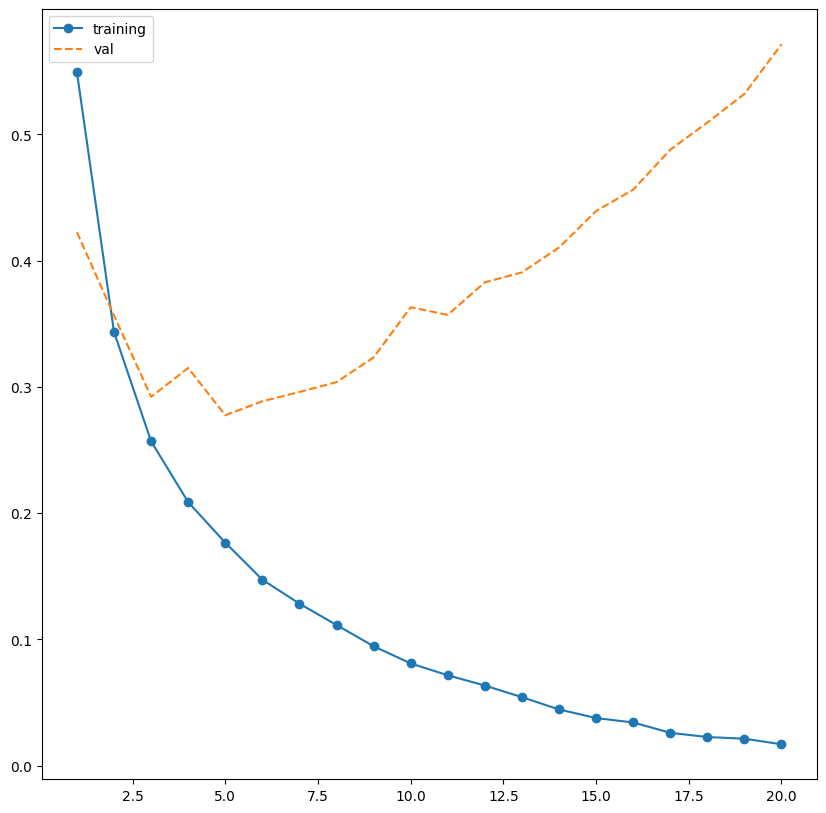

In [20]:
import matplotlib.pyplot as plt

modelb_dict = modelb.history
loss_values = modelb_dict['loss']
val_loss_values = modelb_dict['val_loss']

fig = plt.figure(figsize=(10,10))
epoch = range(1,len(loss_values)+1)
plt.plot(epoch,loss_values, 'o-',label='training')
plt.plot(epoch,val_loss_values, '--',label='val')
plt.legend()
plt.show()

In [21]:
model.evaluate(x_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8554 - loss: 0.6220


[0.6219836473464966, 0.8553599715232849]

### Comparando con un modelo más pequeño

In [22]:
model2 = models.Sequential()
model2.add(layers.Dense(4, activation='relu', input_shape=(10000,)))
model2.add(layers.Dense(4, activation='relu'))
model2.add(layers.Dense(1, activation='sigmoid'))

In [23]:
model2.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
             metrics=['accuracy'])

In [24]:
modelb2 = model2.fit(partial_x_train,
                   partial_y_train,
                   epochs=20,
                   batch_size=512,
                   validation_data=(x_val,y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - accuracy: 0.7421 - loss: 0.6159 - val_accuracy: 0.8356 - val_loss: 0.5401
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8707 - loss: 0.4776 - val_accuracy: 0.8596 - val_loss: 0.4445
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8909 - loss: 0.3871 - val_accuracy: 0.8705 - val_loss: 0.3801
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9044 - loss: 0.3220 - val_accuracy: 0.8783 - val_loss: 0.3394
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9166 - loss: 0.2744 - val_accuracy: 0.8794 - val_loss: 0.3157
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9243 - loss: 0.2396 - val_accuracy: 0.8890 - val_loss: 0.2920
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9332 - loss: 0.2116 - val_accuracy: 0.8897 - val_loss: 0.2809
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9405 - loss: 0.1902 - val_accuracy: 0.8917 - v

## Analizamos resultados

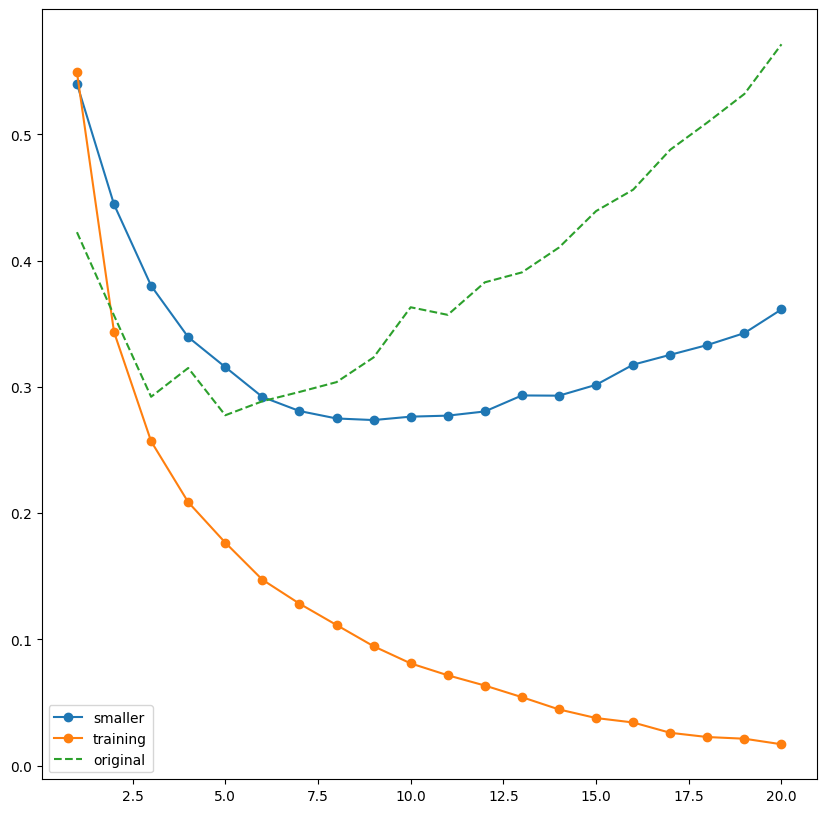

In [25]:
import matplotlib.pyplot as plt

modelb_dict = modelb.history
loss_values = modelb_dict['loss']
val_loss_values = modelb_dict['val_loss']

val_loss_values2 = modelb2.history['val_loss']


fig = plt.figure(figsize=(10,10))
epoch = range(1,len(loss_values)+1)
plt.plot(epoch,val_loss_values2, 'o-',label='smaller')
plt.plot(epoch,loss_values, 'o-',label='training')
plt.plot(epoch,val_loss_values, '--',label='original')
plt.legend()
plt.show()

## Regularización

In [26]:
from keras import regularizers

In [27]:
model3 = models.Sequential()
model3.add(layers.Dense(16, activation='relu', input_shape=(10000,),kernel_regularizer=regularizers.l2(0.001)))
model3.add(layers.Dense(16, activation='relu',kernel_regularizer=regularizers.l2(0.001)))
model3.add(layers.Dense(1, activation='sigmoid'))

In [28]:
model3.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
             metrics=['accuracy'])

In [29]:
modelb3 = model3.fit(partial_x_train,
                   partial_y_train,
                   epochs=20,
                   batch_size=512,
                   validation_data=(x_val,y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - accuracy: 0.7798 - loss: 0.5618 - val_accuracy: 0.8618 - val_loss: 0.4438
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8919 - loss: 0.3772 - val_accuracy: 0.8827 - val_loss: 0.3656
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9195 - loss: 0.2995 - val_accuracy: 0.8790 - val_loss: 0.3548
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9306 - loss: 0.2572 - val_accuracy: 0.8859 - val_loss: 0.3318
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9414 - loss: 0.2281 - val_accuracy: 0.8849 - val_loss: 0.3355
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9481 - loss: 0.2115 - val_accuracy: 0.8849 - val_loss: 0.3405
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9525 - loss: 0.1993 - val_accuracy: 0.8846 - val_loss: 0.3455
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9568 - loss: 0.1914 - val_accuracy: 0.8799 - 

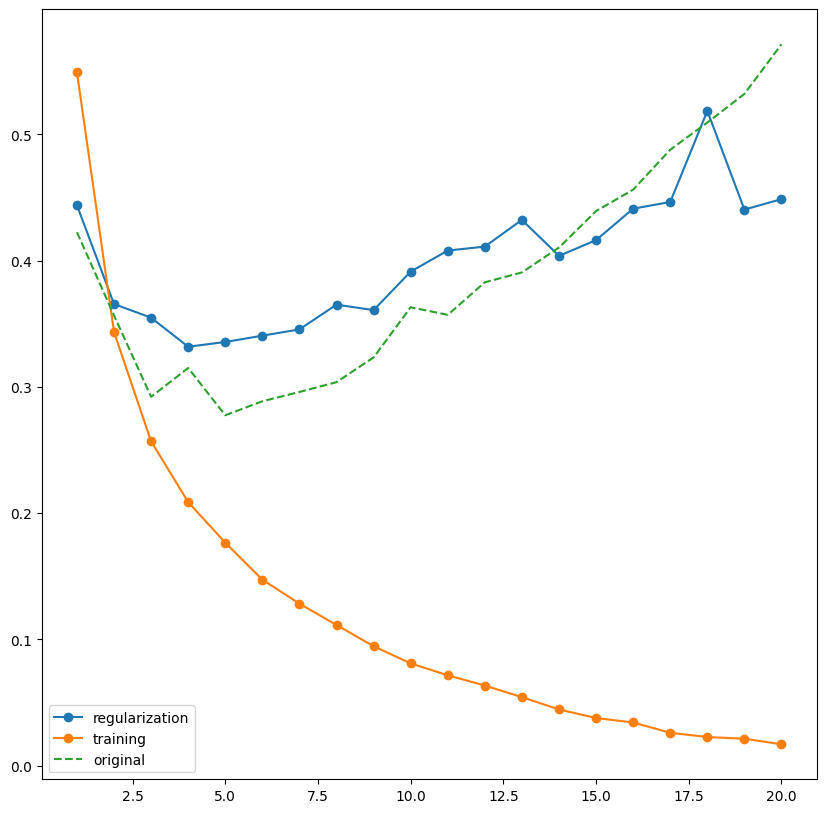

In [30]:
import matplotlib.pyplot as plt

modelb_dict = modelb.history
loss_values = modelb_dict['loss']
val_loss_values = modelb_dict['val_loss']

val_loss_values3 = modelb3.history['val_loss']


fig = plt.figure(figsize=(10,10))
epoch = range(1,len(loss_values)+1)
plt.plot(epoch,val_loss_values3, 'o-',label='regularization')
plt.plot(epoch,loss_values, 'o-',label='training')
plt.plot(epoch,val_loss_values, '--',label='original')
plt.legend()
plt.show()

### Dropout

In [31]:
model4 = models.Sequential()
model4.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model4.add(layers.Dropout(0.5))
model4.add(layers.Dense(16, activation='relu'))
model4.add(layers.Dropout(0.5))
model4.add(layers.Dense(1, activation='sigmoid'))

In [32]:
model4.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
             metrics=['accuracy'])

In [33]:
modelb4 = model4.fit(partial_x_train,
                   partial_y_train,
                   epochs=20,
                   batch_size=512,
                   validation_data=(x_val,y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 126ms/step - accuracy: 0.6295 - loss: 0.6404 - val_accuracy: 0.8163 - val_loss: 0.5418
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.7373 - loss: 0.5311 - val_accuracy: 0.8649 - val_loss: 0.4438
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7981 - loss: 0.4569 - val_accuracy: 0.8752 - val_loss: 0.3670
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8391 - loss: 0.4008 - val_accuracy: 0.8859 - val_loss: 0.3302
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8687 - loss: 0.3567 - val_accuracy: 0.8855 - val_loss: 0.3050
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.8889 - loss: 0.3168 - val_accuracy: 0.8905 - val_loss: 0.2800
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9022 - loss: 0.2839 - val_accuracy: 0.8848 - val_loss: 0.2863
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9172 - loss: 0.2549 - val_accuracy: 0.8882 - 

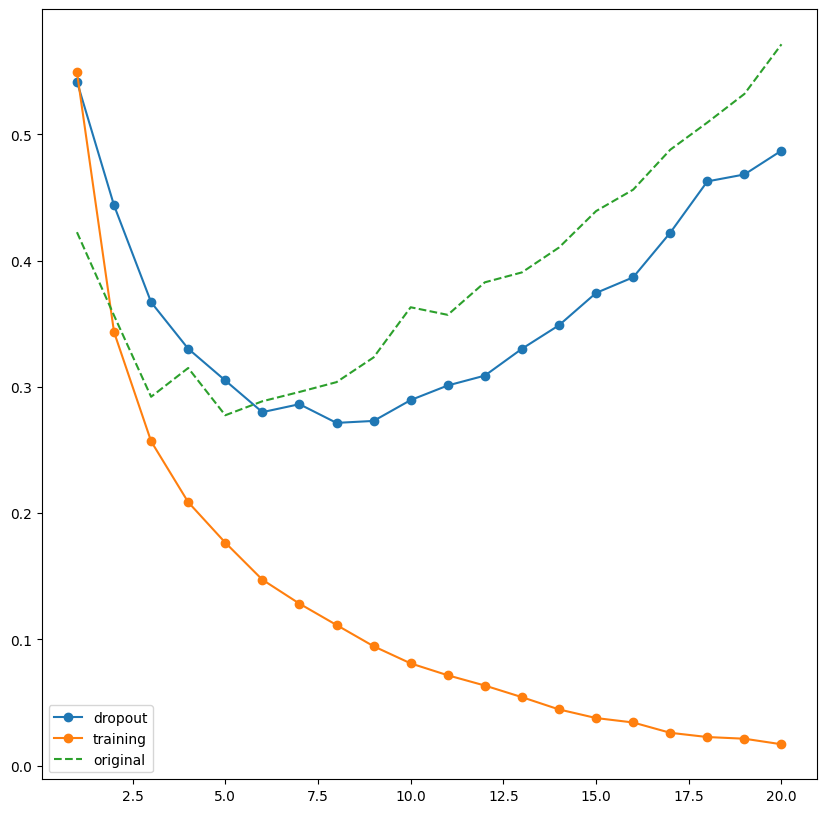

In [34]:
modelb_dict = modelb.history
loss_values = modelb_dict['loss']
val_loss_values = modelb_dict['val_loss']

val_loss_values4 = modelb4.history['val_loss']


fig = plt.figure(figsize=(10,10))
epoch = range(1,len(loss_values)+1)
plt.plot(epoch,val_loss_values4, 'o-',label='dropout')
plt.plot(epoch,loss_values, 'o-',label='training')
plt.plot(epoch,val_loss_values, '--',label='original')
plt.legend()
plt.show()

## Predicciones

In [35]:
predictions = model.predict(x_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [36]:
predictions[10]

array([0.95730424], dtype=float32)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 228ms/step - accuracy: 0.6486 - loss: 0.6598 - val_accuracy: 0.8337 - val_loss: 0.5550
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7824 - loss: 0.5312 - val_accuracy: 0.8504 - val_loss: 0.4573
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8337 - loss: 0.4456 - val_accuracy: 0.8720 - val_loss: 0.3957
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8712 - loss: 0.3782 - val_accuracy: 0.8750 - val_loss: 0.3599
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8952 - loss: 0.3344 - val_accuracy: 0.8776 - val_loss: 0.3401
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9134 - loss: 0.2914 - val_accuracy: 0.8808 - val_loss: 0.3280
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9282 - loss: 0.2604 - val_accuracy: 0.8781 - val_loss: 0.3310
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9411 - loss: 0.2318 - val_accuracy: 0.8832 - 

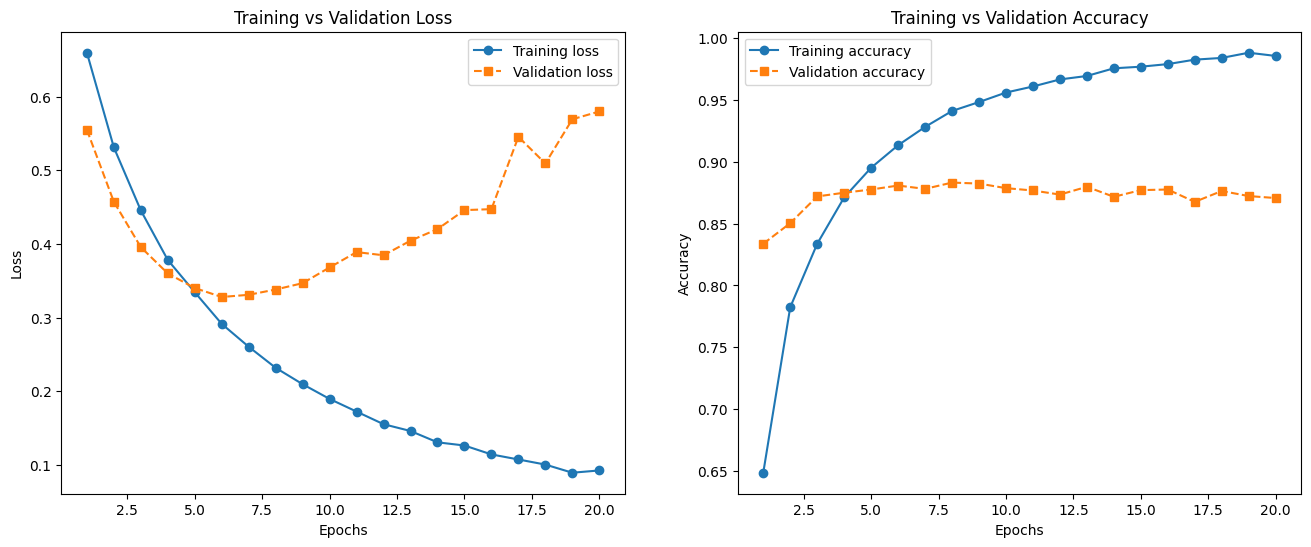

In [60]:
from keras import regularizers
import matplotlib.pyplot as plt

# 1. Mezclamos y separamos datos
indices = np.arange(x_train.shape[0])
np.random.shuffle(indices)
x_train_shuffled = x_train[indices]
y_train_shuffled = y_train[indices]

x_val = x_train_shuffled[:10000]
partial_x_train = x_train_shuffled[10000:]
y_val = y_train_shuffled[:10000]
partial_y_train = y_train_shuffled[10000:]

# 2. Modelo optimizado
model_final = models.Sequential([
    layers.Dense(16, activation='relu',
                 kernel_regularizer=regularizers.l1_l2(l1=1e-5, l2=1e-4),
                 input_shape=(10000,)),
    layers.Dropout(0.4),
    layers.Dense(16, activation='relu',
                 kernel_regularizer=regularizers.l1_l2(l1=1e-5, l2=1e-4)),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')
])

model_final.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])

# 3. Entrenamiento
history_final = model_final.fit(partial_x_train, partial_y_train,
                                epochs=20, batch_size=512,
                                validation_data=(x_val, y_val))

# 4. Visualización Completa (Loss y Accuracy)
history_dict = history_final.history
loss = history_dict['loss']
val_loss = history_dict['val_loss']
acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
epochs_range = range(1, len(loss) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de Pérdida (usando el estilo que sugeriste)
ax1.plot(epochs_range, loss, 'o-', label='Training loss')
ax1.plot(epochs_range, val_loss, 's--', label='Validation loss')
ax1.set_title('Training vs Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

# Gráfico de Precisión
ax2.plot(epochs_range, acc, 'o-', label='Training accuracy')
ax2.plot(epochs_range, val_acc, 's--', label='Validation accuracy')
ax2.set_title('Training vs Validation Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.show()